<a href="https://colab.research.google.com/github/devpatel0005/SMS-Spam-Detection/blob/main/sms_spam_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 65.7 MB/s eta 0:00:00


In [46]:
import re
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from gensim.models import Word2Vec
import tensorflow
from tensorflow import keras
from keras.models import Sequential
from keras.optimizers import Adam
from keras.regularizers import l2
from tensorflow.keras.layers import Bidirectional,LSTM,Dense,Embedding,Dropout,BatchNormalization
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

In [23]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os

# --- Kaggle API setup and dataset download for Colab environment ---

# Install Kaggle API client
!pip install kaggle --quiet

# Create .kaggle directory and move kaggle.json for authentication
# The kaggle.json file is expected to be present at /content/kaggle.json as per kernel state.
!mkdir -p ~/.kaggle
!mv /content/kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

# Download the 'SMS Spam Collection Dataset' to the current directory
# The dataset ID is 'uciml/sms-spam-collection-dataset'
!kaggle datasets download -d uciml/sms-spam-collection-dataset -p .

# Unzip the downloaded file. The zip file usually contains 'spam.csv'.
# The downloaded file is typically named after the dataset ID, so 'sms-spam-collection-dataset.zip'.
!unzip -o sms-spam-collection-dataset.zip

# Verify the contents after unzipping
print("Files in current directory after download and extraction:")
for dirname, _, filenames in os.walk('.'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# --- End of Kaggle API setup ---

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Dataset URL: https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset
License(s): unknown
  0% 0.00/211k [00:00<?, ?B/s]
100% 211k/211k [00:00<00:00, 565MB/s]
Archive:  sms-spam-collection-dataset.zip
  inflating: spam.csv                
Files in current directory after download and extraction:
./sms-spam-collection-dataset.zip
./spam.csv
./.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
./.config/active_config
./.config/.last_update_check.json
./.config/default_configs.db
./.config/.last_survey_prompt.yaml
./.config/gce
./.config/config_sentinel
./.config/.last_opt_in_prompt.yaml
./.config/configurations/config_default
./.config/logs/2026.02.06/14.31.28.771044.log
./.config/logs/2026.02.06/14.31.35.535753.log
./.config/logs/2026.02.06/14.31.19.332851.log
./.config/logs/2026.02.06/14.30.32.592228.log
./.config/logs/2026.02.06/14.31.45.734270.log
./.config/logs/2026.02.06/14.31.44.938153.log
./sample_data/anscombe.json
./sample_data/README.md
./sample_da

In [5]:
df=pd.read_csv('spam.csv', encoding='latin-1')

In [6]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
4403,ham,"Sorry, I'll call later &lt;#&gt; mins",NaN,NaN,NaN
2070,spam,Sexy Singles are waiting for you! Text your AG...,NaN,NaN,NaN
3016,ham,One of the joys in lifeis waking up each daywi...,NaN,NaN,NaN
219,ham,Yeah you should. I think you can use your gt a...,NaN,NaN,NaN
1906,ham,And stop being an old man. You get to build sn...,NaN,NaN,NaN


In [8]:
df=df[['v1','v2']]

In [9]:
df.sample(5)

,v1,v2
4376,ham,How much is torch in 9ja.
2372,ham,Watching tv lor... Y she so funny we bluff her...
2936,ham,Lol yep did that yesterday. Already got my fir...
3950,ham,Hi dude hw r u da realy mising u today
2771,ham,Then ur sis how?


In [10]:
df.columns=['Label','message']

# text preprocessing

In [32]:
sms=[]
for i in range(len(df)):
  text=re.sub('[^a-zA-Z]',' ',df['message'][i])
  text=text.lower()
  text=text.split()
  text=[WordNetLemmatizer().lemmatize(word) for word in text if word not in stopwords.words('english')]
  text=' '.join(text)
  sms.append([text])


In [33]:
sms

[['go jurong point crazy available bugis n great world la e buffet cine got amore wat'],
 ['ok lar joking wif u oni'],
 ['free entry wkly comp win fa cup final tkts st may text fa receive entry question std txt rate c apply'],
 ['u dun say early hor u c already say'],
 ['nah think go usf life around though'],
 ['freemsg hey darling week word back like fun still tb ok xxx std chgs send rcv'],
 ['even brother like speak treat like aid patent'],
 ['per request melle melle oru minnaminunginte nurungu vettam set callertune caller press copy friend callertune'],
 ['winner valued network customer selected receivea prize reward claim call claim code kl valid hour'],
 ['mobile month u r entitled update latest colour mobile camera free call mobile update co free'],
 ['gonna home soon want talk stuff anymore tonight k cried enough today'],
 ['six chance win cash pound txt csh send cost p day day tsandcs apply reply hl info'],
 ['urgent week free membership prize jackpot txt word claim c www dbuk 

In [34]:
model=Word2Vec(sms,min_count=1)

- here we have created vectors for each sentence now will create training data out of it

In [43]:
X = []
for msg in sms:
    # msg is a list containing one string, e.g., [['go jurong point crazy available bugis n great world la e buffet cine got amore wat']]
    # We need to process the string inside the list.
    word_vectors = []
    # Split the message string into individual words
    words = msg[0].split()
    for word in words:
        if word in model.wv:
            word_vectors.append(model.wv[word])

    if len(word_vectors) > 0:
        # Average the word vectors to get a sentence vector
        X.append(np.mean(word_vectors, axis=0))
    else:
        # If no words in the message are in the vocabulary, append a zero vector
        X.append(np.zeros(model.vector_size))

X = np.array(X)

# Display the shape of the generated feature matrix
print(f"Shape of feature matrix X: {X.shape}")

Shape of feature matrix X: (5572, 100)


In [44]:
X[0]

array([ 8.56364844e-04,  5.64169604e-03, -3.52907320e-03, -5.32576628e-03,
       -4.49516810e-05, -4.57017962e-03,  3.31221870e-03, -9.53022856e-04,
       -1.33700925e-03,  3.52053205e-03,  6.93764584e-03, -2.46715732e-04,
        1.12097245e-04,  6.92344969e-03,  6.99495990e-03, -2.41758954e-03,
       -4.17845789e-04, -6.38624467e-03,  7.21228716e-04, -2.12454796e-03,
        1.77943299e-03, -7.84756383e-04, -4.30410216e-03,  7.72615056e-03,
       -5.44258486e-03,  6.22861506e-03, -3.22412746e-03,  9.92670073e-04,
       -1.58717507e-03,  5.69509901e-03,  4.21197386e-03, -7.99559988e-04,
        1.71283470e-03,  7.07277679e-04,  2.41334643e-03,  3.43003450e-03,
        3.82632599e-04, -7.42108189e-03, -2.25142413e-03,  2.86398525e-03,
        9.94308735e-04, -1.66280381e-03, -2.67933961e-03, -6.82378840e-03,
        4.81867185e-03, -2.36066990e-03, -3.54832597e-03,  3.88830202e-04,
       -6.10888936e-03, -5.13876788e-03,  5.98019548e-03, -1.32060586e-03,
        1.04958005e-03, -

In [45]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df['Label'])


In [47]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.1,random_state=42)

In [49]:
x_train.shape

(5014, 100)

# LSTM layers expect input with three dimensions: (number_of_samples, number_of_timesteps, number_of_features).

In [48]:
# Reshape x_train and x_test for LSTM input
x_train_reshaped = x_train.reshape(x_train.shape[0], 1, x_train.shape[1])
x_test_reshaped = x_test.reshape(x_test.shape[0], 1, x_test.shape[1])

print(f"Reshaped x_train shape: {x_train_reshaped.shape}")
print(f"Reshaped x_test shape: {x_test_reshaped.shape}")

Reshaped x_train shape: (5014, 1, 100)
Reshaped x_test shape: (558, 1, 100)


- he timesteps dimension is set to 1 because of how we created our X feature matrix.

We processed each message by taking all its words, finding their Word2Vec embeddings, and then averaging those word embeddings to get a single vector. This single vector represents the entire message.

Since each message is already condensed into one representative vector, when we feed it to the LSTM, it's considered a sequence of just one item – that one averaged message vector. If we had kept each word's vector separate and fed them sequentially (e.g., [[word1_vec], [word2_vec], [word3_vec]] for a three-word message), then the timesteps would be the number of words in the message. But in our current setup, each X entry is already the combined representation of a message.



In [50]:
# Define the input dimension (vector dimension for each word)
input_dim = x_train_reshaped.shape[2]

# Build the Bi-LSTM model
model = Sequential()
model.add(Bidirectional(LSTM(128, return_sequences=False), input_shape=(1, input_dim)))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid')) # Binary classification, so 1 output unit with sigmoid activation

# Compile the model
model.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Display model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 256)            │       234,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 234,753 (917.00 KB)

 Trainable params: 234,753 (917.00 KB)

 Non-trainable params: 0 (0.00 B)

- input_shape=(1, input_dim) tells the Bidirectional LSTM to expect input where each sample is a sequence of 1 timestep, and that single timestep is a vector of input_dim features. here 100 is the vector dimension

In [51]:
history = model.fit(x_train_reshaped, y_train, epochs=10, batch_size=32, validation_split=0.1, verbose=1)

Epoch 1/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accuracy: 0.8548 - loss: 0.5914 - val_accuracy: 0.8645 - val_loss: 0.3804
Epoch 2/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.8698 - loss: 0.3623 - val_accuracy: 0.8645 - val_loss: 0.3565
Epoch 3/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8588 - loss: 0.3562 - val_accuracy: 0.8645 - val_loss: 0.3360
Epoch 4/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8670 - loss: 0.3245 - val_accuracy: 0.8705 - val_loss: 0.3195
Epoch 5/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8663 - loss: 0.3246 - val_accuracy: 0.8765 - val_loss: 0.3075
Epoch 6/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8770 - loss: 0.3130 - val_accuracy: 0.8765 - val_loss: 0.2992
Epoch 7/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8883 - loss: 0.2884 - val_accuracy: 0.8805 - val_loss: 0.2945
Epoch 8/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8919 - loss: 0.2784 - val_accuracy:

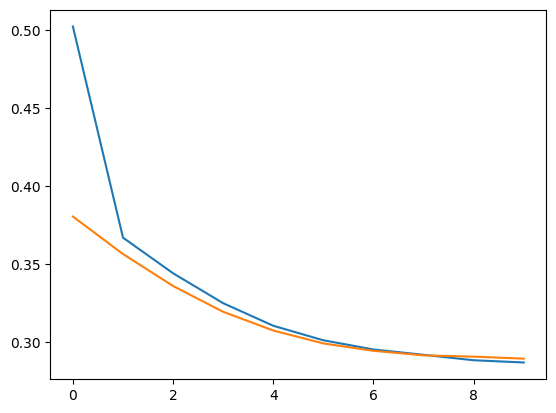

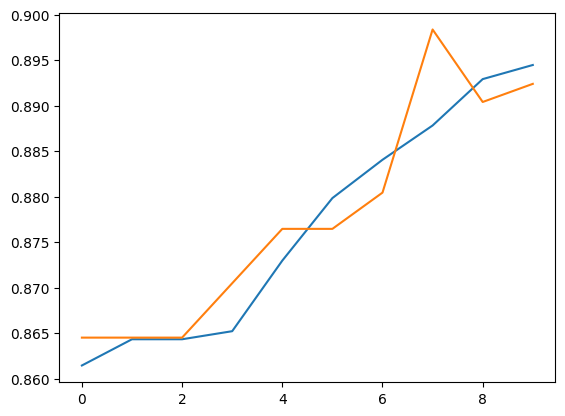

In [53]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])


In [68]:
y_train_pred_probs = model.predict(x_train_reshaped)
y_train_pred = (y_train_pred_probs > 0.5).astype(int)

y_test_pred_probs = model.predict(x_test_reshaped)
y_test_pred = (y_test_pred_probs > 0.5).astype(int)


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [69]:
from sklearn.metrics import classification_report

target_names = ['ham', 'spam']

# Generate the classification report for the training set
report_train = classification_report(y_train, y_train_pred, target_names=target_names)

print("--- Classification Report for Training Data ---")
print(report_train)

--- Classification Report for Training Data ---
              precision    recall  f1-score   support

         ham       0.91      0.97      0.94      4334
        spam       0.68      0.39      0.49       680

    accuracy                           0.89      5014
   macro avg       0.79      0.68      0.72      5014
weighted avg       0.88      0.89      0.88      5014



In [70]:
from sklearn.metrics import classification_report

target_names = ['ham', 'spam']

# Generate the classification report for the test set
report_test = classification_report(y_test, y_test_pred, target_names=target_names)

print("--- Classification Report for Test Data ---")
print(report_test)

--- Classification Report for Test Data ---
              precision    recall  f1-score   support

         ham       0.93      0.98      0.95       491
        spam       0.72      0.46      0.56        67

    accuracy                           0.91       558
   macro avg       0.83      0.72      0.76       558
weighted avg       0.90      0.91      0.91       558

